# Results: Adjusted R² on Test Split

This notebook summarizes model performance using **Adjusted R² on the test split** (other metrics are ignored).

1. Table of test Adjusted R² for every `(model, variant)`.
2. Top-7 `(model, variant)` by test Adjusted R², plus the baseline `(rf, cat)`.
3. Single bar plot comparing the top-7 against the baseline.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

BASELINE = ("rf", "cat")

df = pd.read_csv("metrics.csv")
df.head()

,timestamp,model,target,variant,split,metric,value,std
0,2026-06-08T22:50:37,mlp,price,cat,train,RMSE,225492.579939,4885.176350
1,2026-06-08T22:50:37,mlp,price,cat,train,MAE,148887.301068,3241.517412
2,2026-06-08T22:50:37,mlp,price,cat,train,MAPE,32.914196,1.853806
3,2026-06-08T22:50:37,mlp,price,cat,train,R2,0.575621,0.016026
4,2026-06-08T22:50:37,mlp,price,cat,train,Adjusted_R2,0.573796,0.016095


In [2]:
# Keep only Adjusted R2 on the test split; one row per (model, variant).
# Carry the across-fold std (from k-fold CV) so the plots can show error bars.
mask = (df["split"] == "test") & (df["metric"] == "Adjusted_R2")
cols = ["model", "variant", "value"] + (["std"] if "std" in df.columns else [])
adj = df.loc[mask, cols].rename(columns={"value": "adjusted_r2_test"})
if "std" in adj.columns:
    adj = adj.rename(columns={"std": "adjusted_r2_std"})
else:
    # Older metrics.csv (single split, no CV) has no std column.
    adj["adjusted_r2_std"] = float("nan")
adj = adj.sort_values("adjusted_r2_test", ascending=False).reset_index(drop=True)
adj

,model,variant,adjusted_r2_test,adjusted_r2_std
0,ensemble_rf,coord_only,0.794072,0.048278
1,ensemble_rf,tgt,0.782338,0.053387
2,ensemble_mlp,tgt,0.778766,0.049512
3,ensemble_mgbdt,tgt,0.770932,0.051063
4,ensemble_rf,tgt_only,0.769660,0.052728
5,mgbdt,tgt,0.764823,0.043293
6,ensemble_mgbdt,tgt_only,0.762102,0.057541
7,rf,tgt,0.754131,0.048246
8,ensemble_mgbdt,coord_only,0.752825,0.049252
9,rf,coord_only,0.752530,0.046122


## 2. Variant comparison for `rf` (cat vs coord_only vs tgt_only vs tgt)


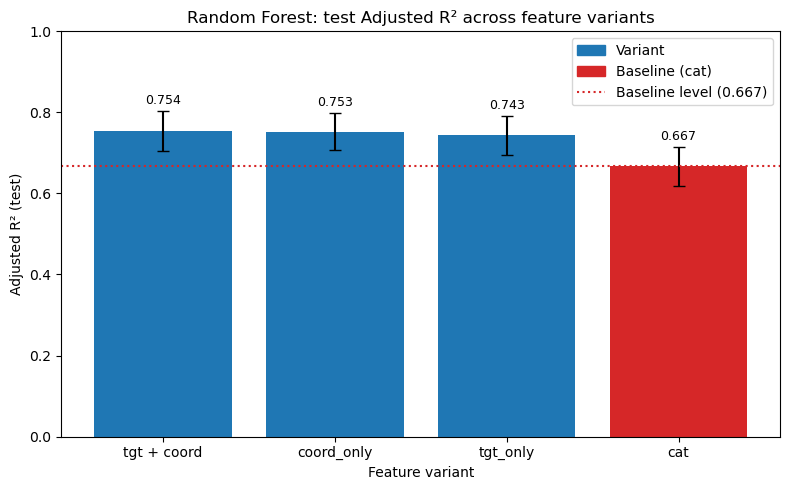

In [3]:
# Compare the rf model across feature variants, ordered from baseline to richest.
VARIANT_ORDER = ["tgt", "coord_only", "tgt_only", "cat"]

rf_variants = adj[adj["model"] == "rf"].copy()
rf_variants["variant"] = pd.Categorical(
    rf_variants["variant"], categories=VARIANT_ORDER, ordered=True
)
rf_variants = rf_variants.sort_values("variant").reset_index(drop=True)


# Display label: "tgt" uses target encoding *and* coords, so show it as "tgt + coord".
# Leave "tgt_only" (and everything else) untouched.
def variant_label(v):
    return "tgt + coord" if ("tgt" in v and "tgt_only" not in v) else v


x_labels = [variant_label(v) for v in rf_variants["variant"].astype(str)]

fig, ax = plt.subplots(figsize=(8, 5))

# Baseline variant (cat) highlighted; others share a single colour.
colors = ["#d62728" if v == "cat" else "#1f77b4" for v in rf_variants["variant"]]
# yerr = across-fold std from k-fold CV (omitted for older single-split metrics).
bars = ax.bar(
    x_labels,
    rf_variants["adjusted_r2_test"],
    yerr=rf_variants["adjusted_r2_std"],
    capsize=4,
    color=colors,
)

# Dotted reference line at the cat baseline level.
baseline_val = rf_variants.loc[
    rf_variants["variant"] == "cat", "adjusted_r2_test"
].iloc[0]
ax.axhline(baseline_val, color="#d62728", linestyle=":", linewidth=1.5)

ax.set_ylabel("Adjusted R² (test)")
ax.set_xlabel("Feature variant")
ax.set_title("Random Forest: test Adjusted R² across feature variants")
ax.set_ylim(0, 1)

# Place each value label above the error-bar cap.
for bar, val, s in zip(
    bars, rf_variants["adjusted_r2_test"], rf_variants["adjusted_r2_std"]
):
    off = 0.0 if pd.isna(s) else s
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + off + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color="#1f77b4", label="Variant"),
    plt.Rectangle((0, 0), 1, 1, color="#d62728", label="Baseline (cat)"),
    plt.Line2D(
        [0],
        [0],
        color="#d62728",
        linestyle=":",
        linewidth=1.5,
        label=f"Baseline level ({baseline_val:.3f})",
    ),
]
ax.legend(handles=legend_handles)

fig.tight_layout()
fig.savefig("rf_variant_comparison_test.png", dpi=150)
plt.show()

In [4]:
top7 = adj.head(7).copy()

# Ensure the baseline is present for comparison (added if not already in top-7).
baseline_row = adj[(adj["model"] == BASELINE[0]) & (adj["variant"] == BASELINE[1])]
is_baseline = (top7["model"] == BASELINE[0]) & (top7["variant"] == BASELINE[1])

if not is_baseline.any():
    plot_df = pd.concat([top7, baseline_row], ignore_index=True)
else:
    plot_df = top7.copy()

plot_df["is_baseline"] = (plot_df["model"] == BASELINE[0]) & (
    plot_df["variant"] == BASELINE[1]
)
# Display label only: rename "mgbdt" -> "XGBoost" and "tgt" -> "tgt + coord"
# (via variant_label); the underlying "model"/"variant" columns are unchanged.
plot_df["label"] = (
    plot_df["model"] + " / " + plot_df["variant"].map(variant_label)
).str.replace("mgbdt", "XGBoost", regex=False)
plot_df = plot_df.sort_values("adjusted_r2_test", ascending=False).reset_index(
    drop=True
)
plot_df

,model,variant,adjusted_r2_test,adjusted_r2_std,is_baseline,label
0,ensemble_rf,coord_only,0.794072,0.048278,False,ensemble_rf / coord_only
1,ensemble_rf,tgt,0.782338,0.053387,False,ensemble_rf / tgt + coord
2,ensemble_mlp,tgt,0.778766,0.049512,False,ensemble_mlp / tgt + coord
3,ensemble_mgbdt,tgt,0.770932,0.051063,False,ensemble_XGBoost / tgt + coord
4,ensemble_rf,tgt_only,0.769660,0.052728,False,ensemble_rf / tgt_only
5,mgbdt,tgt,0.764823,0.043293,False,XGBoost / tgt + coord
6,ensemble_mgbdt,tgt_only,0.762102,0.057541,False,ensemble_XGBoost / tgt_only
7,rf,cat,0.666937,0.047486,True,rf / cat


## 3. Comparison plot


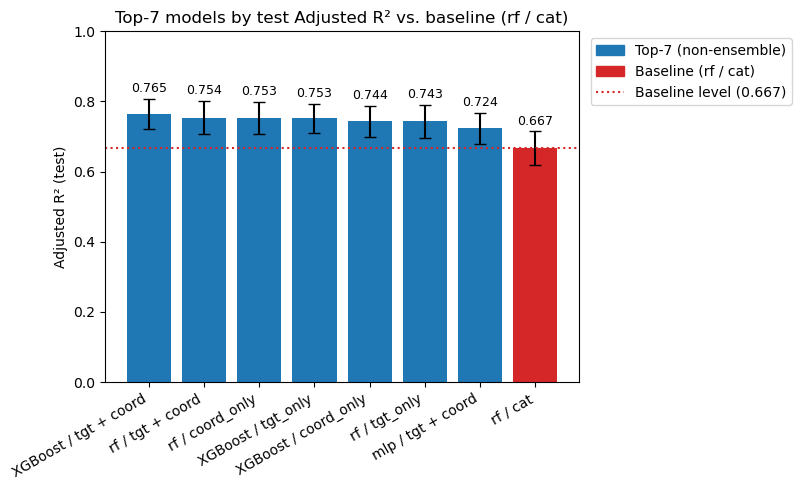

In [5]:
# Comparison restricted to non-ensemble models.
# Top-7 (model, variant) by test Adjusted R² after dropping any ensemble_* model,
# plus the baseline (rf / cat) for reference.
no_ens = adj[~adj["model"].str.startswith("ensemble")].copy()
top7_no_ens = no_ens.head(7).copy()

baseline_row_no_ens = no_ens[
    (no_ens["model"] == BASELINE[0]) & (no_ens["variant"] == BASELINE[1])
]
is_baseline_no_ens = (top7_no_ens["model"] == BASELINE[0]) & (
    top7_no_ens["variant"] == BASELINE[1]
)

if not is_baseline_no_ens.any():
    plot_df_no_ens = pd.concat([top7_no_ens, baseline_row_no_ens], ignore_index=True)
else:
    plot_df_no_ens = top7_no_ens.copy()

plot_df_no_ens["is_baseline"] = (plot_df_no_ens["model"] == BASELINE[0]) & (
    plot_df_no_ens["variant"] == BASELINE[1]
)
# Display label only: rename "mgbdt" -> "XGBoost" and "tgt" -> "tgt + coord"
# (via variant_label); the underlying "model"/"variant" columns are unchanged.
plot_df_no_ens["label"] = (
    plot_df_no_ens["model"] + " / " + plot_df_no_ens["variant"].map(variant_label)
).str.replace("mgbdt", "XGBoost", regex=False)
plot_df_no_ens = plot_df_no_ens.sort_values(
    "adjusted_r2_test", ascending=False
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#d62728" if b else "#1f77b4" for b in plot_df_no_ens["is_baseline"]]
# yerr = across-fold std from k-fold CV (omitted for older single-split metrics).
bars = ax.bar(
    plot_df_no_ens["label"],
    plot_df_no_ens["adjusted_r2_test"],
    yerr=plot_df_no_ens["adjusted_r2_std"],
    capsize=4,
    color=colors,
)

# Horizontal reference line at the baseline level.
baseline_val = plot_df_no_ens.loc[
    plot_df_no_ens["is_baseline"], "adjusted_r2_test"
].iloc[0]
ax.axhline(
    baseline_val,
    color="#d62728",
    linestyle=":",
    linewidth=1.5,
    label=f"Baseline level ({baseline_val:.3f})",
)

ax.set_ylabel("Adjusted R² (test)")
ax.set_title("Top-7 models by test Adjusted R² vs. baseline (rf / cat)")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
for label in ax.get_xticklabels():
    label.set_ha("right")

# Place each value label above the error-bar cap.
for bar, val, s in zip(
    bars, plot_df_no_ens["adjusted_r2_test"], plot_df_no_ens["adjusted_r2_std"]
):
    off = 0.0 if pd.isna(s) else s
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + off + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color="#1f77b4", label="Top-7 (non-ensemble)"),
    plt.Rectangle((0, 0), 1, 1, color="#d62728", label="Baseline (rf / cat)"),
    plt.Line2D(
        [0],
        [0],
        color="#d62728",
        linestyle=":",
        linewidth=1.5,
        label=f"Baseline level ({baseline_val:.3f})",
    ),
]
# Anchor the legend outside the axes (upper right) so it never covers the bars/labels.
ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.01, 1.0))

fig.tight_layout()
fig.savefig("top5_adjusted_r2_test_no_ensemble.png", dpi=150, bbox_inches="tight")
plt.show()

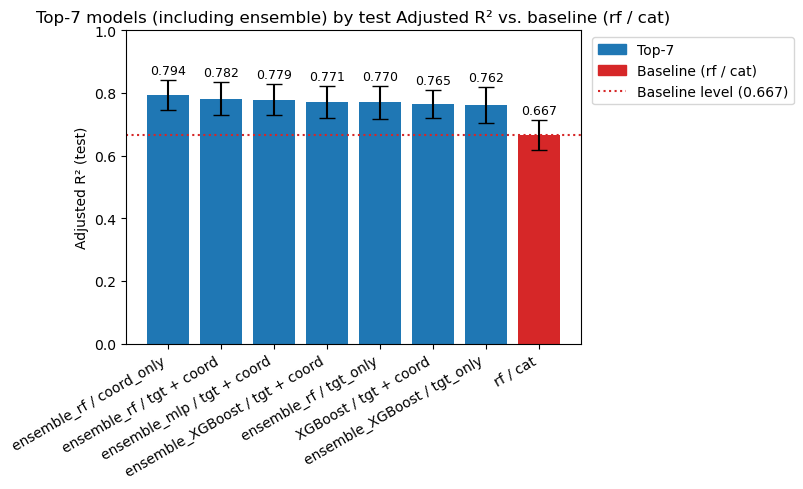

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#d62728" if b else "#1f77b4" for b in plot_df["is_baseline"]]
# yerr = across-fold std from k-fold CV (omitted for older single-split metrics).
bars = ax.bar(
    plot_df["label"],
    plot_df["adjusted_r2_test"],
    yerr=plot_df["adjusted_r2_std"],
    capsize=6,
    color=colors,
)

# Horizontal reference line at the baseline level.
baseline_val = plot_df.loc[plot_df["is_baseline"], "adjusted_r2_test"].iloc[0]
ax.axhline(
    baseline_val,
    color="#d62728",
    linestyle=":",
    linewidth=1.5,
    label=f"Baseline level ({baseline_val:.3f})",
)

ax.set_ylabel("Adjusted R² (test)")
ax.set_title(
    "Top-7 models (including ensemble) by test Adjusted R² vs. baseline (rf / cat)"
)
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
for label in ax.get_xticklabels():
    label.set_ha("right")

# Place each value label above the error-bar cap.
for bar, val, s in zip(bars, plot_df["adjusted_r2_test"], plot_df["adjusted_r2_std"]):
    off = 0.0 if pd.isna(s) else s
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + off + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color="#1f77b4", label="Top-7"),
    plt.Rectangle((0, 0), 1, 1, color="#d62728", label="Baseline (rf / cat)"),
    plt.Line2D(
        [0],
        [0],
        color="#d62728",
        linestyle=":",
        linewidth=1.5,
        label=f"Baseline level ({baseline_val:.3f})",
    ),
]
# Anchor the legend outside the axes (upper right) so it never covers the bars/labels.
ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.01, 1.0))

fig.tight_layout()
fig.savefig("top5_adjusted_r2_test.png", dpi=150, bbox_inches="tight")
plt.show()